#### Load data and import lib

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

In [2]:
from ydata_profiling import ProfileReport

In [5]:
data = pd.read_csv("big Propety sale.csv", low_memory=False)

#### Get basic information

In [7]:
data.head()

,_id,PARID,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYADDRESS,PROPERTYCITY,PROPERTYSTATE,PROPERTYUNIT,PROPERTYZIP,MUNICODE,...,HALFBATHS,HEATINGCOOLING,HEATINGCOOLINGDESC,FIREPLACES,BSMTGARAGE,FINISHEDLIVINGAREA,CARDNUMBER,ALT_ID,TAXYEAR,ASOFDATE
0,26660041,0001D00125000000,100.0,,5TH AVE,PITTSBURGH,PA,,15222.0,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,2026-04-01
1,26660042,0001D00127000000,23.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,2026-04-01
2,26660043,0001D00128000000,24.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,2026-04-01
3,26660044,0001D00130000000,26.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,2026-04-01
4,26660045,0001D00132000000,115.0,-119,FORBES AVE,PITTSBURGH,PA,,15222.0,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,2026-04-01


In [9]:
data.tail()

,_id,PARID,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYADDRESS,PROPERTYCITY,PROPERTYSTATE,PROPERTYUNIT,PROPERTYZIP,MUNICODE,...,HALFBATHS,HEATINGCOOLING,HEATINGCOOLINGDESC,FIREPLACES,BSMTGARAGE,FINISHEDLIVINGAREA,CARDNUMBER,ALT_ID,TAXYEAR,ASOFDATE
584891,27244932,0887C00325000000,6127.0,,PLEASANT ST,SOUTH PARK,PA,,15129.0,945,...,1.0,B,Central Heat with AC,0.0,0.0,1045.0,1.0,NaN,2026,2026-04-01
584892,27244933,0772H00012000000,942.0,,WESTCHESTER RD,SOUTH PARK,PA,,15129.0,945,...,0.0,B,Central Heat with AC,1.0,2.0,1338.0,1.0,NaN,2026,2026-04-01
584893,27244934,0320D00137000000,565.0,,MIRANDA RD,PITTSBURGH,PA,,15241.0,950,...,2.0,B,Central Heat with AC,1.0,2.0,2712.0,1.0,NaN,2026,2026-04-01
584894,27244935,0319G00008000000,4.0,,MITCHELL DR,PITTSBURGH,PA,,15241.0,950,...,0.0,B,Central Heat with AC,1.0,1.0,1246.0,1.0,NaN,2026,2026-04-01
584895,27244936,0884E00015000000,1230.0,,BARNSTAPLE DR,SOUTH PARK,PA,,15129.0,945,...,1.0,B,Central Heat with AC,0.0,2.0,1872.0,1.0,NaN,2026,2026-04-01


In [8]:
data.shape

(584896, 87)

In [10]:
data.columns

Index(['_id', 'PARID', 'PROPERTYHOUSENUM', 'PROPERTYFRACTION',
       'PROPERTYADDRESS', 'PROPERTYCITY', 'PROPERTYSTATE', 'PROPERTYUNIT',
       'PROPERTYZIP', 'MUNICODE', 'MUNIDESC', 'SCHOOLCODE', 'SCHOOLDESC',
       'LEGAL1', 'LEGAL2', 'LEGAL3', 'NEIGHCODE', 'NEIGHDESC', 'TAXCODE',
       'TAXDESC', 'TAXSUBCODE', 'TAXSUBCODE_DESC', 'OWNERCODE', 'OWNERDESC',
       'CLASS', 'CLASSDESC', 'USECODE', 'USEDESC', 'LOTAREA', 'HOMESTEADFLAG',
       'CLEANGREEN', 'FARMSTEADFLAG', 'ABATEMENTFLAG', 'RECORDDATE',
       'SALEDATE', 'SALEPRICE', 'SALECODE', 'SALEDESC', 'DEEDBOOK', 'DEEDPAGE',
       'PREVSALEDATE', 'PREVSALEPRICE', 'PREVSALEDATE2', 'PREVSALEPRICE2',
       'CHANGENOTICEADDRESS1', 'CHANGENOTICEADDRESS2', 'CHANGENOTICEADDRESS3',
       'CHANGENOTICEADDRESS4', 'COUNTYBUILDING', 'COUNTYLAND', 'COUNTYTOTAL',
       'COUNTYEXEMPTBLDG', 'LOCALBUILDING', 'LOCALLAND', 'LOCALTOTAL',
       'FAIRMARKETBUILDING', 'FAIRMARKETLAND', 'FAIRMARKETTOTAL', 'STYLE',
       'STYLEDESC', 'STORIES', 

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584896 entries, 0 to 584895
Data columns (total 87 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   _id                   584896 non-null  int64  
 1   PARID                 584896 non-null  object 
 2   PROPERTYHOUSENUM      584891 non-null  float64
 3   PROPERTYFRACTION      584896 non-null  object 
 4   PROPERTYADDRESS       584896 non-null  object 
 5   PROPERTYCITY          584892 non-null  object 
 6   PROPERTYSTATE         584896 non-null  object 
 7   PROPERTYUNIT          584896 non-null  object 
 8   PROPERTYZIP           584894 non-null  float64
 9   MUNICODE              584896 non-null  int64  
 10  MUNIDESC              584896 non-null  object 
 11  SCHOOLCODE            584896 non-null  int64  
 12  SCHOOLDESC            584896 non-null  object 
 13  LEGAL1                584870 non-null  object 
 14  LEGAL2                521169 non-null  object 
 15  

In [12]:
data.describe()

,_id,PROPERTYHOUSENUM,PROPERTYZIP,MUNICODE,SCHOOLCODE,OWNERCODE,USECODE,LOTAREA,SALEPRICE,PREVSALEPRICE,...,CONDITION,TOTALROOMS,BEDROOMS,FULLBATHS,HALFBATHS,FIREPLACES,BSMTGARAGE,FINISHEDLIVINGAREA,CARDNUMBER,TAXYEAR
count,5.848960e+05,584891.000000,584894.000000,584896.000000,584896.000000,584896.000000,584896.000000,5.848960e+05,5.763350e+05,4.205630e+05,...,449181.000000,449157.000000,449219.000000,449151.000000,444561.000000,407684.000000,424239.000000,449263.000000,449263.000000,584896.0
mean,2.695249e+07,1346.805839,15166.467392,685.850575,28.913573,12.779323,77.019482,3.287632e+04,1.599134e+05,1.114656e+05,...,3.121163,6.487656,3.040717,1.502875,0.494164,0.376731,0.705458,1714.064020,1.003815,2026.0
std,1.688451e+05,2014.703746,83.099213,340.485075,15.045105,3.756691,152.428816,7.460322e+05,8.743859e+05,1.046416e+06,...,0.781826,1.757265,0.906943,0.700576,0.571355,0.553117,0.825255,818.781753,0.115019,0.0
min,2.666004e+07,0.000000,15003.000000,101.000000,1.000000,10.000000,10.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2026.0
25%,2.680626e+07,115.000000,15108.000000,202.000000,17.000000,10.000000,10.000000,3.200000e+03,1.000000e+00,1.000000e+00,...,3.000000,5.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1177.000000,1.000000,2026.0
50%,2.695249e+07,505.000000,15203.000000,873.000000,29.000000,12.000000,10.000000,6.871000e+03,5.475200e+04,2.860000e+04,...,3.000000,6.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1506.000000,1.000000,2026.0
75%,2.709871e+07,1679.000000,15221.000000,927.000000,46.000000,12.000000,70.000000,1.357000e+04,1.700000e+05,1.110000e+05,...,3.000000,7.000000,3.000000,2.000000,1.000000,1.000000,1.000000,2032.000000,1.000000,2026.0
max,2.724494e+07,39392.000000,16229.000000,953.000000,50.000000,28.000000,998.000000,3.836329e+08,1.793957e+08,2.929078e+08,...,8.000000,87.000000,18.000000,13.000000,16.000000,22.000000,6.000000,33444.000000,45.000000,2026.0


#### Check Missing Values

In [13]:
data.isnull().sum()

_id                        0
PARID                      0
PROPERTYHOUSENUM           5
PROPERTYFRACTION           0
PROPERTYADDRESS            0
                       ...  
FINISHEDLIVINGAREA    135633
CARDNUMBER            135633
ALT_ID                558821
TAXYEAR                    0
ASOFDATE                   0
Length: 87, dtype: int64

#### Visualize missing values

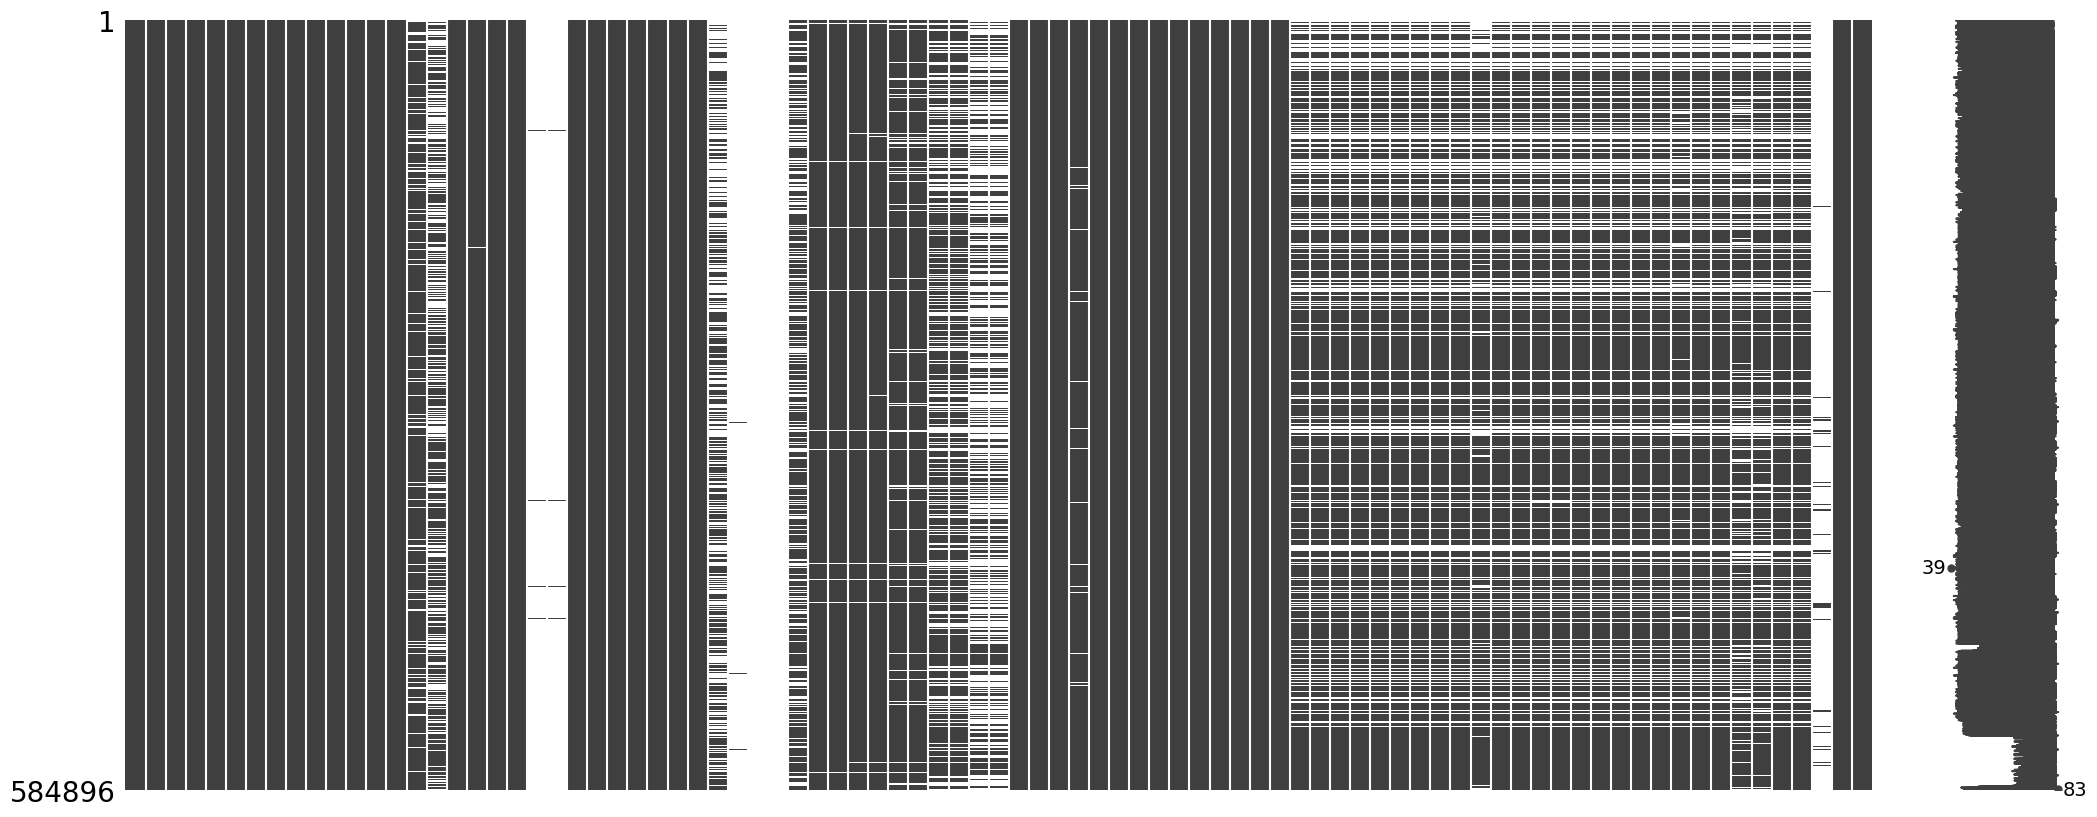

In [14]:
msno.matrix(data)
plt.show()

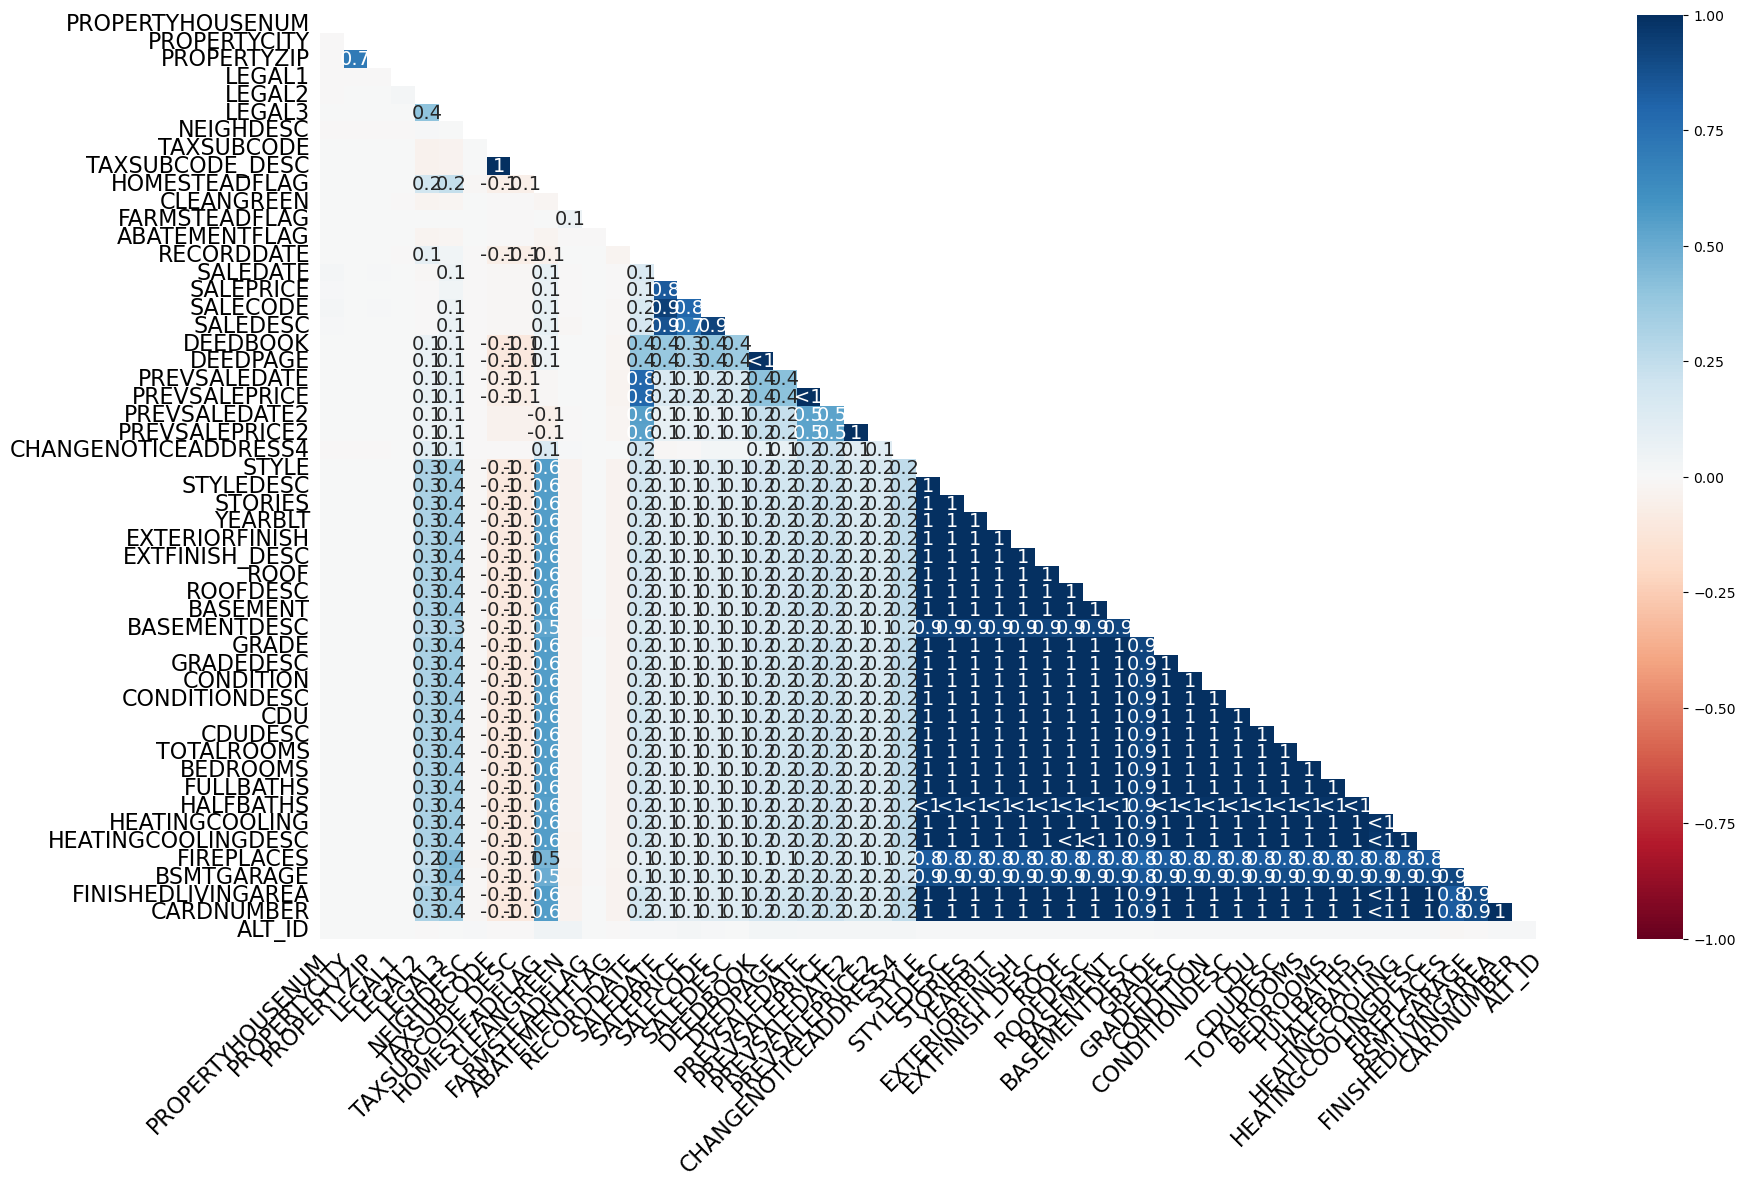

In [16]:
msno.heatmap(data)
plt.show()

#### Check Duplicate Rows

In [18]:
data.duplicated().sum()

0

#### Analyze Data Types

In [19]:
data.dtypes

_id                     int64
PARID                  object
PROPERTYHOUSENUM      float64
PROPERTYFRACTION       object
PROPERTYADDRESS        object
                       ...   
FINISHEDLIVINGAREA    float64
CARDNUMBER            float64
ALT_ID                 object
TAXYEAR                 int64
ASOFDATE               object
Length: 87, dtype: object

In [20]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['_id', 'PROPERTYHOUSENUM', 'PROPERTYZIP', 'MUNICODE', 'SCHOOLCODE',
       'OWNERCODE', 'USECODE', 'LOTAREA', 'SALEPRICE', 'PREVSALEPRICE',
       'PREVSALEPRICE2', 'CHANGENOTICEADDRESS4', 'COUNTYBUILDING',
       'COUNTYLAND', 'COUNTYTOTAL', 'COUNTYEXEMPTBLDG', 'LOCALBUILDING',
       'LOCALLAND', 'LOCALTOTAL', 'FAIRMARKETBUILDING', 'FAIRMARKETLAND',
       'FAIRMARKETTOTAL', 'STORIES', 'YEARBLT', 'EXTERIORFINISH', 'ROOF',
       'BASEMENT', 'CONDITION', 'TOTALROOMS', 'BEDROOMS', 'FULLBATHS',
       'HALFBATHS', 'FIREPLACES', 'BSMTGARAGE', 'FINISHEDLIVINGAREA',
       'CARDNUMBER', 'TAXYEAR'],
      dtype='object')

In [22]:
cat_cols

Index(['PARID', 'PROPERTYFRACTION', 'PROPERTYADDRESS', 'PROPERTYCITY',
       'PROPERTYSTATE', 'PROPERTYUNIT', 'MUNIDESC', 'SCHOOLDESC', 'LEGAL1',
       'LEGAL2', 'LEGAL3', 'NEIGHCODE', 'NEIGHDESC', 'TAXCODE', 'TAXDESC',
       'TAXSUBCODE', 'TAXSUBCODE_DESC', 'OWNERDESC', 'CLASS', 'CLASSDESC',
       'USEDESC', 'HOMESTEADFLAG', 'CLEANGREEN', 'FARMSTEADFLAG',
       'ABATEMENTFLAG', 'RECORDDATE', 'SALEDATE', 'SALECODE', 'SALEDESC',
       'DEEDBOOK', 'DEEDPAGE', 'PREVSALEDATE', 'PREVSALEDATE2',
       'CHANGENOTICEADDRESS1', 'CHANGENOTICEADDRESS2', 'CHANGENOTICEADDRESS3',
       'STYLE', 'STYLEDESC', 'EXTFINISH_DESC', 'ROOFDESC', 'BASEMENTDESC',
       'GRADE', 'GRADEDESC', 'CONDITIONDESC', 'CDU', 'CDUDESC',
       'HEATINGCOOLING', 'HEATINGCOOLINGDESC', 'ALT_ID', 'ASOFDATE'],
      dtype='object')

#### Univariate Analysis (Single Column)
##### for numeric column

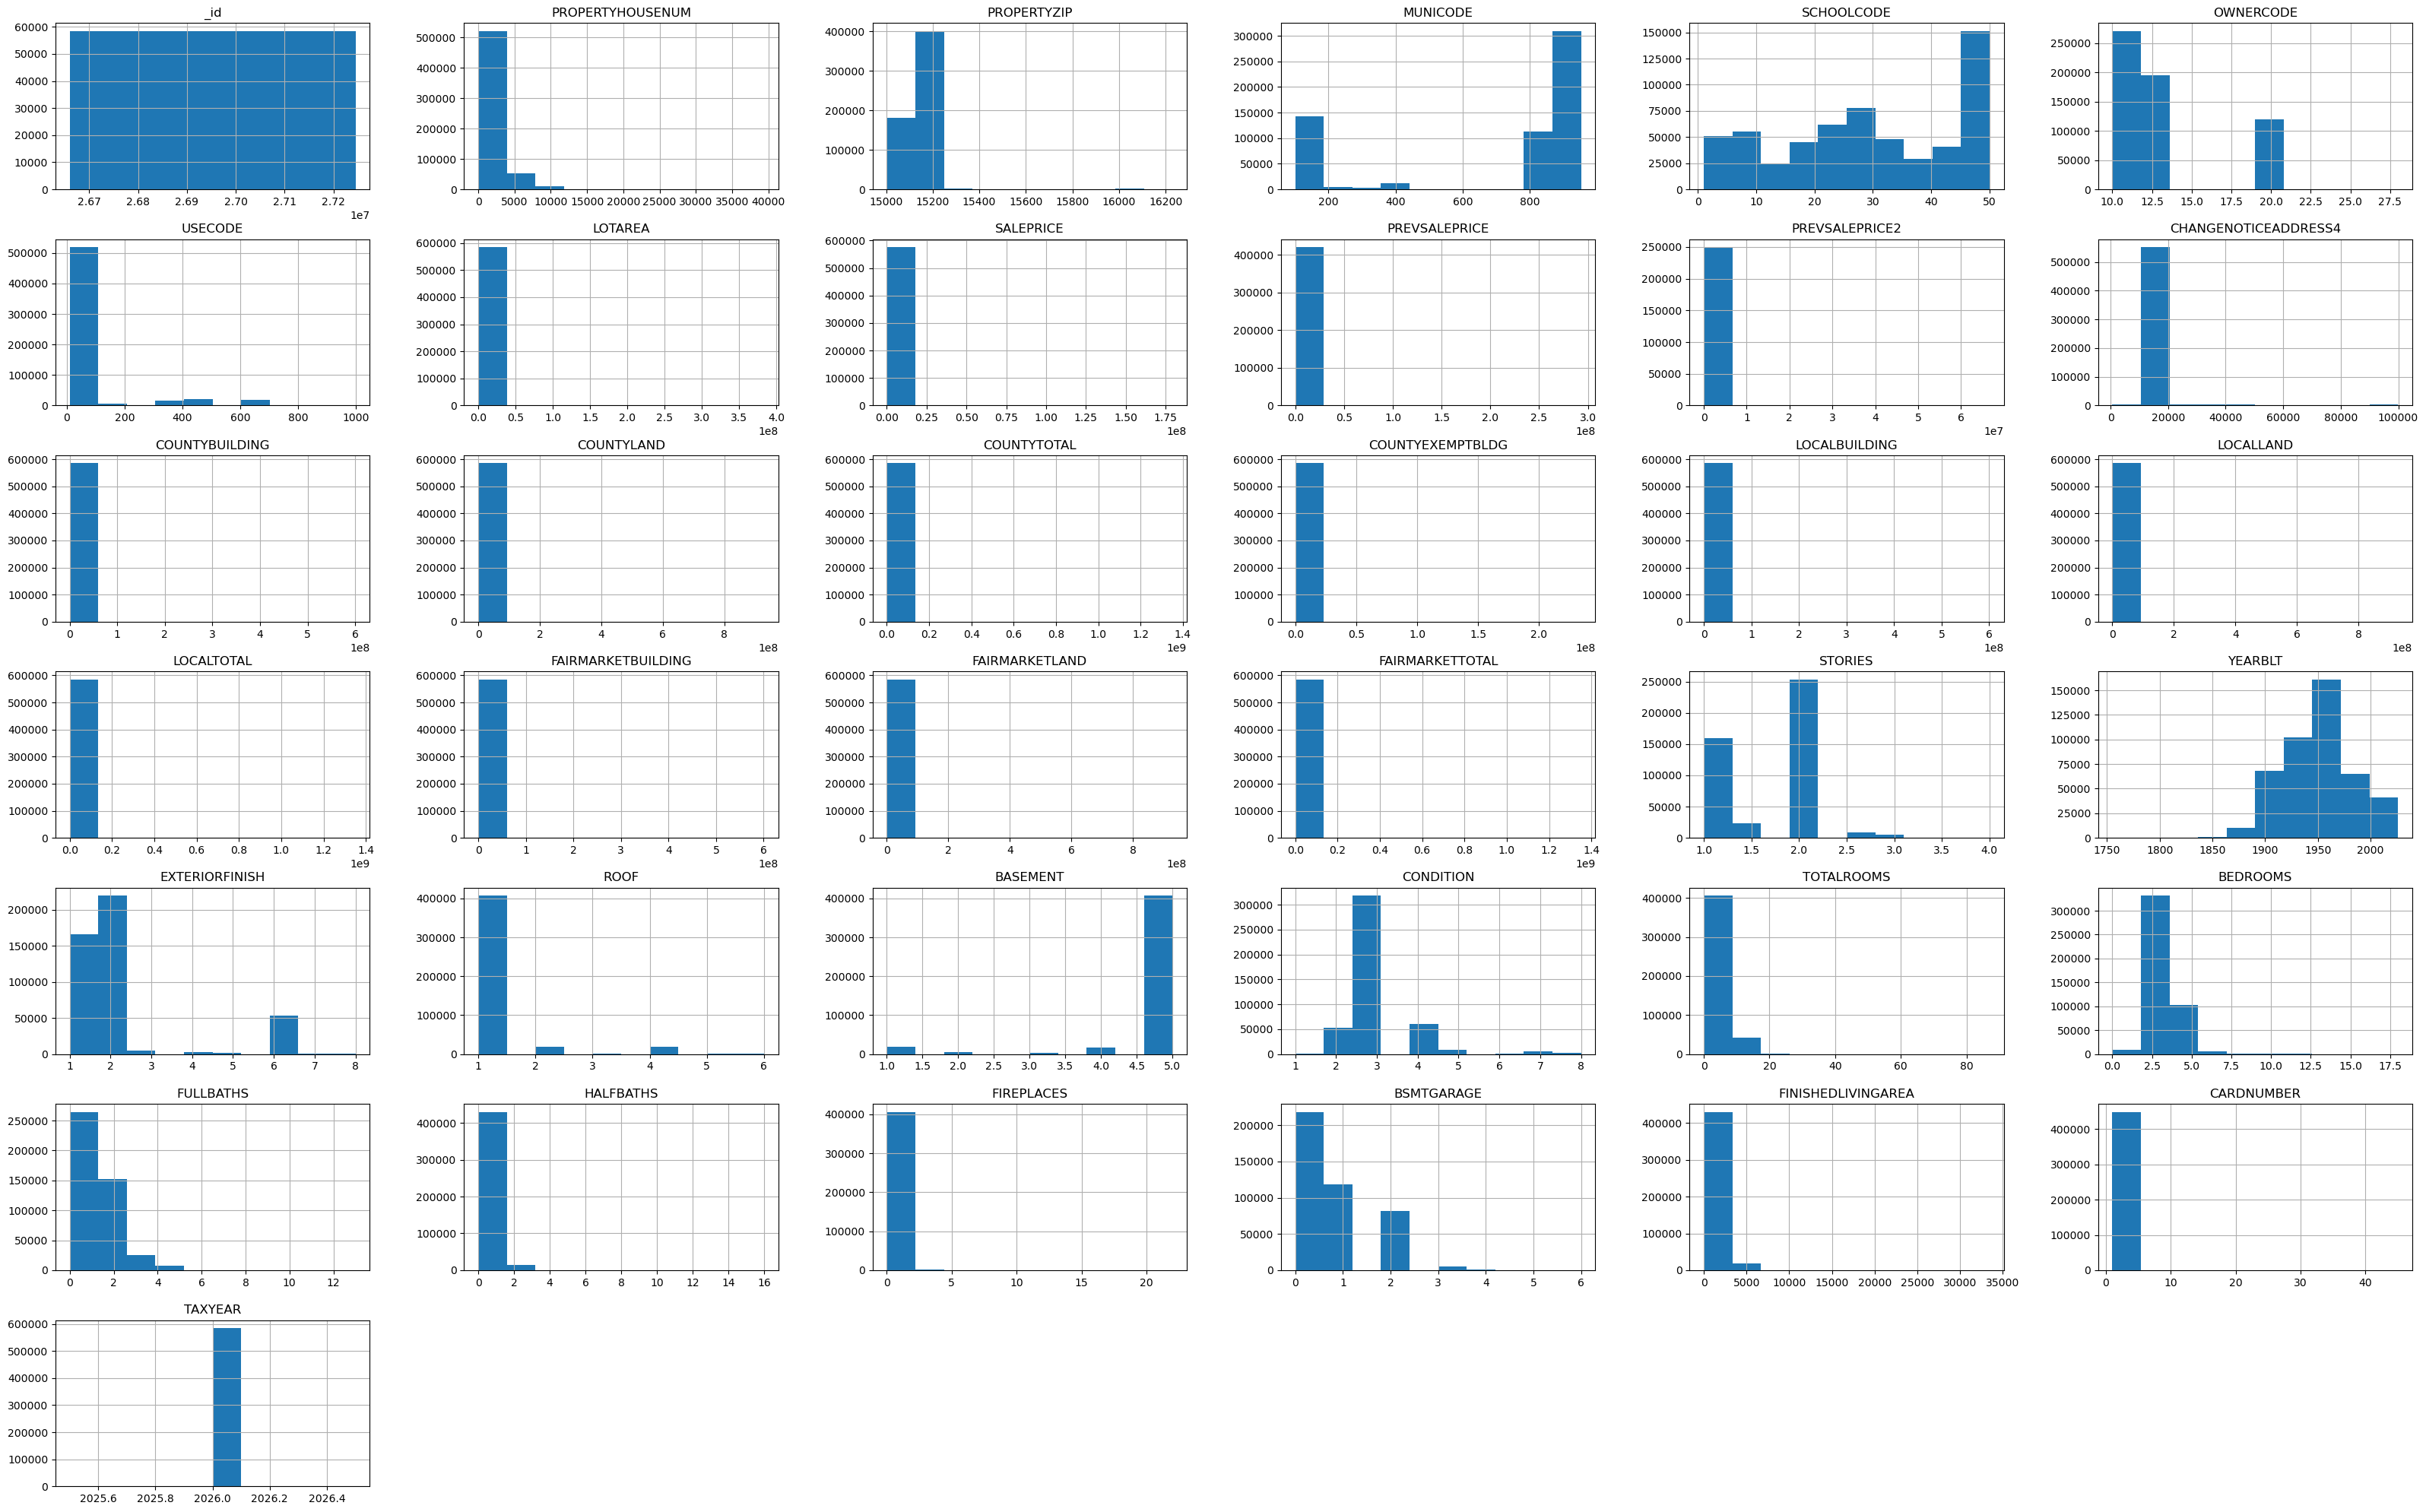

In [40]:
data[num_cols].hist(figsize=(40,25))
plt.show()

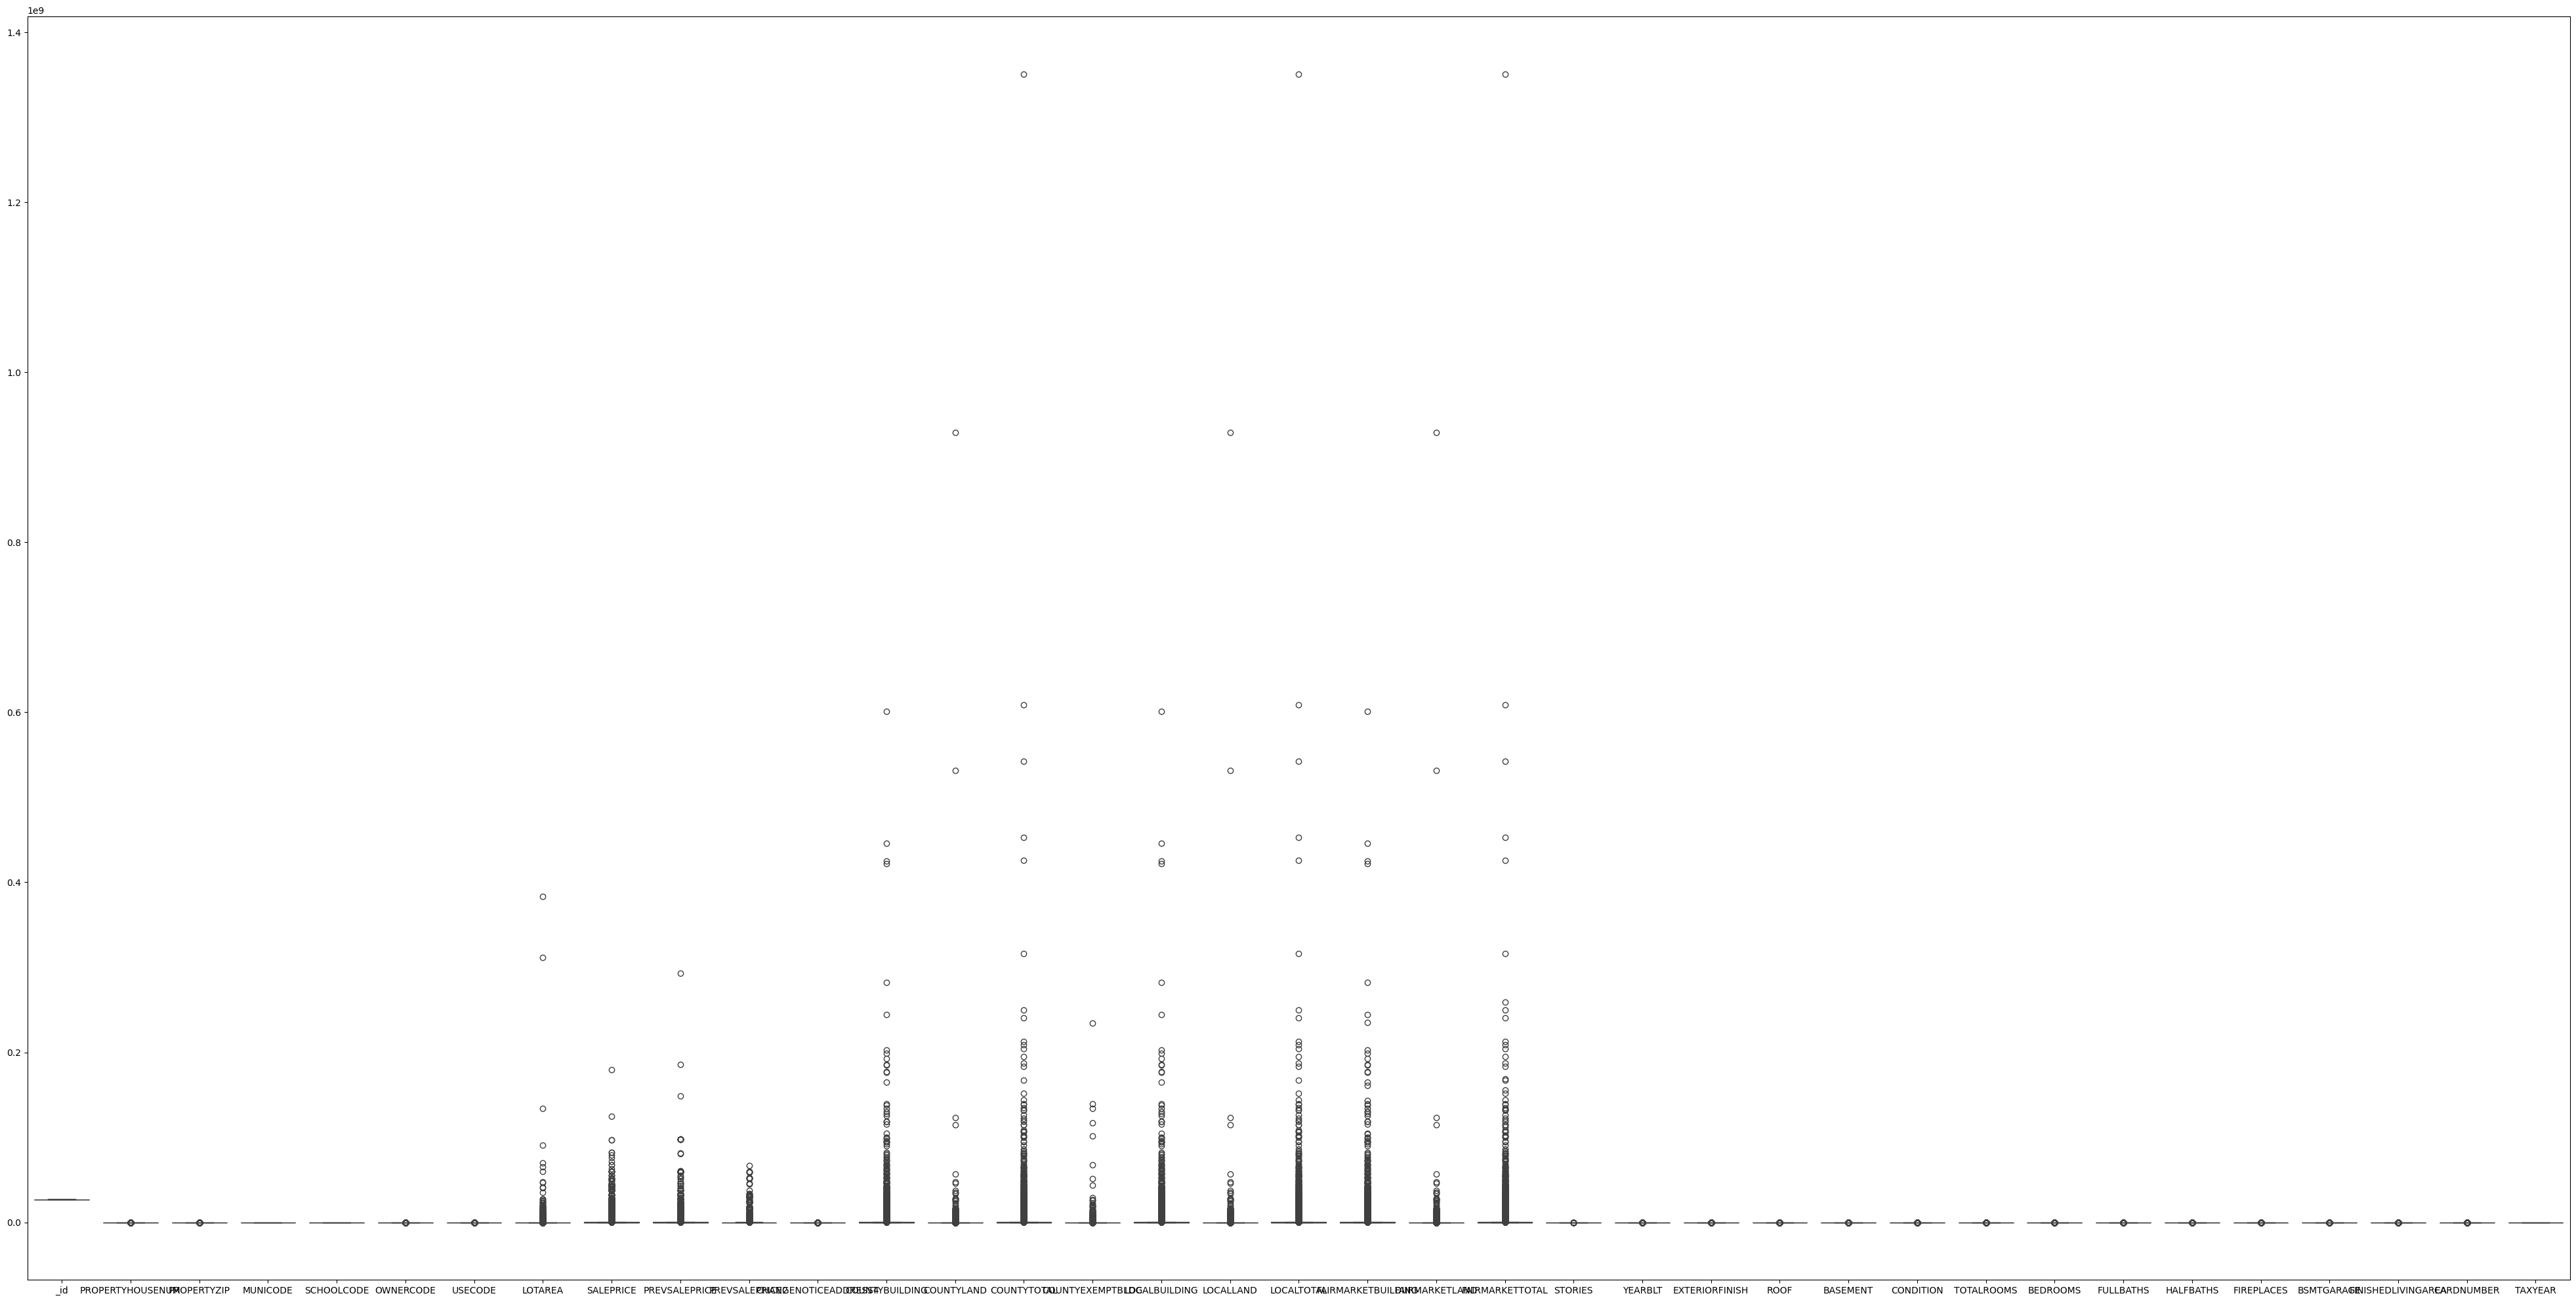

In [45]:
plt.figure(figsize=(50,25))
sns.boxplot(data=data[num_cols])
plt.show()

#### Correlation Analysis